In [3]:
import pandas as pd
import numpy as np


In [4]:
df=pd.read_csv("powerplant_data.csv")

In [5]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [8]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=56
)

In [11]:
df.shape

(9568, 5)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [13]:
import torch
import torch.nn as nn

In [14]:
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)

In [15]:
X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)

In [16]:
y_train_tesnors=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

In [17]:
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [18]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tesnors)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [19]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [20]:
### Deeplearning

##Define ANN Model

class ANN(nn.Module):
    def __init__(self):
        super (ANN,self).__init__()

        self.model=nn.Sequential(
        #1st hidden layer
            nn.Linear(X_train.shape[1],6),

            nn.ReLU(),


        #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

        #output layer
            nn.Linear(6,1),
    )

    def forward(self,x):
        return self.model(x)
    
    

In [21]:
import torch.optim as optim

model=ANN()




# loss,optimizer define karte hain iss step main in creating model
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [22]:
# train the ann
train_losses=[]
validation_losses=[]

best_val_loss=float("inf")
epochs=100

for epoch in range(epochs):
    model.train()
    running_loss=0.0


    for xb,yb in train_loader:
        # xb=features of 1 batch
        # yb =labels of 1 batch

        optimizer.zero_grad()

        outputs=model(xb) # forward prop. predicted outputs for this batch
        loss=criterion(outputs,yb)

        loss.backward()  #back pro..  compute gradients

        optimizer.step()  # params updatest i.e, weights and bias
  

        running_loss+=loss.item()  # here loss is tensor so swe are converting it to py float

    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)



    #validation
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():
        for xb,yb in test_loader:

            outputs=model(xb) # forward prop. predicted outputs for this batch
            loss=criterion(outputs,yb)

        # loss.backward()  #back pro..  compute gradients

        # optimizer.step()  # params updatest i.e, weights and bias
  

            running_val_loss+=loss # here loss is tensor so swe are converting it to py float

    epoch_test_loss=running_val_loss/len(test_loader)
    validation_losses.append(epoch_test_loss)

    print(f"epoc ${epoch+1}/{epochs} ==> train loss= ${epoch_train_loss} & val loss= {epoch_test_loss}")

    if epoch_test_loss<best_val_loss:
        best_val_loss=epoch_test_loss
        torch.save(model.state_dict(),"best_model.pt")  #.pt or .pth



epoc $1/100 ==> train loss= $206704.35520833332 & val loss= 204817.859375
epoc $2/100 ==> train loss= $199524.68626302082 & val loss= 189614.71875
epoc $3/100 ==> train loss= $172106.560546875 & val loss= 151302.8125
epoc $4/100 ==> train loss= $129068.02421875 & val loss= 108252.9609375
epoc $5/100 ==> train loss= $92628.1875813802 & val loss= 79424.2109375
epoc $6/100 ==> train loss= $70062.78453776041 & val loss= 60566.82421875
epoc $7/100 ==> train loss= $52307.942545572914 & val loss= 42867.90234375
epoc $8/100 ==> train loss= $34834.59359944661 & val loss= 26091.791015625
epoc $9/100 ==> train loss= $19769.433219401042 & val loss= 13188.4775390625
epoc $10/100 ==> train loss= $9219.041318766276 & val loss= 5790.86962890625
epoc $11/100 ==> train loss= $4210.468159993489 & val loss= 3179.704345703125
epoc $12/100 ==> train loss= $2657.7548899332683 & val loss= 2361.348876953125
epoc $13/100 ==> train loss= $2023.2350118001302 & val loss= 1845.8695068359375
epoc $14/100 ==> train l

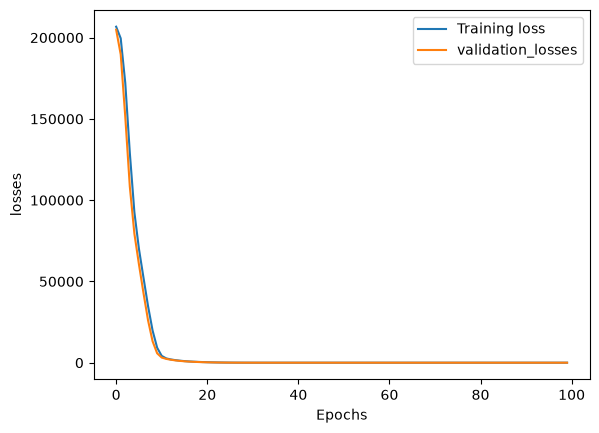

In [23]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "train_loss":train_losses,
    "val_loss":validation_losses
})

plt.plot(loss_df["train_loss"],label="Training loss")
plt.plot(loss_df["val_loss"],label="validation_losses")

plt.xlabel("Epochs")
plt.ylabel("losses")

plt.legend()

In [24]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [25]:
#loading best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [27]:
#evaluate the model

# 1. MSE for training and testing data
# 2.R2 or r2 score

model.eval()
with torch.no_grad():
    train_pred=model(X_train_tensor)
    test_pred=model(X_test_tensor)


    train_mse_loss=criterion(train_pred,y_train_tesnors)
    test_mse_loss=criterion(test_pred,y_test_tensor)

    print("Training MSE :",train_mse_loss.item())
    print("Testing MSE :",test_mse_loss.item())



Training MSE : 20.78917694091797
Testing MSE : 20.7310733795166


In [28]:
from sklearn.metrics import r2_score

print("r^2 score :",r2_score(y_test,test_pred))

r^2 score : 0.9286505333804382


In [29]:
predicted_DF=pd.DataFrame(test_pred.numpy(),columns=["Predicted Values"])
actual_DF=pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_DF,actual_DF],axis=1)

,Predicted Values,Actual Values
0,445.797363,449.11
1,447.790283,448.27
2,480.503479,483.56
3,463.405701,462.59
4,454.182037,460.24
...,...,...
1909,425.157532,431.74
1910,449.061462,444.59
1911,446.204651,442.44
1912,445.178772,441.78
